In [5]:
from sklearn import datasets
import numpy as np
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs 
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

Exercise1: Given two features $X_1$ and $X_2$ and function $g(X_1,X_2) = 2X_1 - 4X_2+1$ decide which of the following observarions belong to the same groups:
    
1. $X_1 = 1$,  $X_2 = -2$
2. $X_1 = 3$,  $X_2 = 1$
3. $X_1 = -1$, $X_2 = 1$
4. $X_1 = 0$,  $X_2 = 2$
5. $X_1 = 0$,  $X_2 = 0$
    
Interpret the coefficients of the function $g$.

In [2]:
import numpy as np
X = [[1,-2], [3,1], [-1,1], [0,2], [0,0]]

def fun(x1,x2):
    return (2*x1 -4*x2 +1)

y=[]
for (x1,x2) in X:
    y.append(fun(x1,x2))

print(y)

categ = (np.array(y) > 0).astype(int)
print(categ)

#coefficients interpretation:
#x2 stonger determines the category: 
#if x2 value is further from 0 than x1 value, then x2 determines the category

[11, 3, -5, -7, 1]
[1 1 0 0 1]


<h4> Exercise2: Consider the Digits dataset. Is the dataset balanced? Divide the data into training and test sets using an 8:2 ratio. Build an SVM classifier using the training set. Then, print the confusion matrix and the classification report for the training set.

In [3]:
from sklearn.datasets import load_digits

digits = load_digits()

X = digits['data']
y = digits['target']

from collections import Counter
print(Counter(int(x) for x in y))
#data set is balanced

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

svm = SVC(kernel='linear', C=0.01, random_state=42)
svm.fit(X_train, y_train)

print(f"Svm score: {svm.score(X_test, y_test)}\n") #accuracy

from sklearn.metrics import confusion_matrix
print(f'Confusion matrix: \n{confusion_matrix(y_test, svm.predict(X_test))}\n') #confusion matrix

from sklearn.metrics import classification_report
print(f'Classification report: \n{classification_report(y_test, svm.predict(X_test), target_names = [str(num) for num in list(range(10))])}')

Counter({3: 183, 1: 182, 5: 182, 4: 181, 6: 181, 9: 180, 7: 179, 0: 178, 2: 177, 8: 174})
Svm score: 0.9805555555555555

Confusion matrix: 
[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  1  0  0 45  0  0  0  0  0]
 [ 0  0  0  0  0 47  0  0  0  0]
 [ 0  0  0  0  0  0 35  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  1]
 [ 0  0  0  0  0  1  0  0 29  0]
 [ 0  0  0  1  1  0  0  1  0 37]]

Classification report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       0.97      0.97      0.97        34
           4       0.98      0.98      0.98        46
           5       0.96      1.00      0.98        47
           6       1.00      1.00      1.00        35
           7       0.97      0.97      0.97        34
           8     

https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators

<h4> Exercise 3: Consider the diabetes dataset.

- Is the dataset balanced?
- Split the data into training and test sets (8:2).
- Tune the hyperparameters using GridSearch and Cross-validation.
- Print the confusion matrix and classification report for the test set.

In [2]:
import pandas as pd
df = pd.read_csv("diabetes.csv", sep =",")


In [3]:
df.describe()
#mean 0.13 -> unbalanced, non-diabetes dominant

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [8]:
X = df.drop(columns=["Diabetes_binary"])
y = df["Diabetes_binary"]

pipe_svc = Pipeline([('scl', StandardScaler()),
                     ('clf', SVC(random_state=1))])

param_range = [0.001, 0.01, 0.1, 1.0, 10.0]

param_grid = [{'clf__C':param_range, 'clf__kernel':['linear']},
              {'clf__C':param_range, 'clf__kernel':['rbf'], 'clf__gamma':param_range}]

gs = GridSearchCV(estimator=pipe_svc, param_grid=param_grid, scoring='accuracy', cv=10, n_jobs=-1) #cv-cross validation

#X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=10000,
    stratify=y,
    random_state=42
)

gs = gs.fit(X_train, y_train) 

print(gs.best_score_, gs.best_params_, gs.score(X_test, y_test))

0.8621999999999999 {'clf__C': 10.0, 'clf__gamma': 0.01, 'clf__kernel': 'rbf'} 0.8629308929743926


In [10]:
print(gs.score(X_test, y_test)) #accuracy
print()

from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, gs.predict(X_test))) #confusion matrix
print()

from sklearn.metrics import classification_report
print(classification_report(y_test, gs.predict(X_test), target_names = ['0','1']))

0.8629308929743926

[[208466   1261]
 [ 32140   1813]]

              precision    recall  f1-score   support

           0       0.87      0.99      0.93    209727
           1       0.59      0.05      0.10     33953

    accuracy                           0.86    243680
   macro avg       0.73      0.52      0.51    243680
weighted avg       0.83      0.86      0.81    243680



* Example: Calculate the distance between the point $P(3,-2)$ and the funtion $f(x) = x^2$.

$f(x) = \sqrt{(x-3)^2+(x^2+2)}$ - distance between $(x,x^2)$ and $(3,-2)$.

$\min_x \sqrt{(x-3)^2+(x^2+2)} = \min_x [(x-3)^2+(x^2+2)] = \min_x [x^2-6x+9+x^4+4x^2+4] = \min_x [x^4+5x^2-6x+13] \approx 11.30$ for $x \approx 0.54$

<h4> Exercise4 (non-linear functions):
    
- Given the following data, propose an example $f(x)=ax^2$ that separate the data. Visualize the results. 
    
- Find $a$ that maximize the margin between the data and $f(x)=ax^2$. Visualize the results.

0.43434343434343436


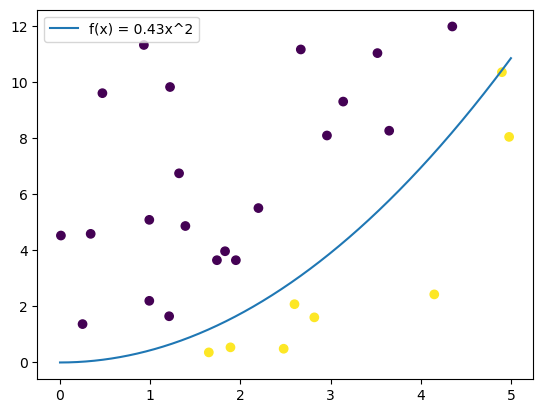

In [89]:
X = np.array([[1.22, 9.83], [2.6, 2.08], [2.82, 1.61], [0.99, 2.2], [1.89, 0.54], [1.74, 3.65], [0.01, 4.53], [1.21, 1.65], [1.65, 0.36], [2.48, 0.49], [2.67, 11.17], [3.52, 11.04], [1.83, 3.97], [4.98, 8.05], [0.25, 1.37], [3.14, 9.31], [2.2, 5.51], [3.65, 8.27], [0.34, 4.59], [0.47, 9.61], [0.99, 5.09], [4.15, 2.43], [4.9, 10.36], [0.93, 11.33], [2.96, 8.1], [1.95, 3.65], [4.35, 11.99], [1.39, 4.87], [1.32, 6.75]])
y = np.array([0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0])

x_par = np.linspace(0, 5, 1000)

def fun(a,x):
    return a*x**2

coef = []
best_score = 0
best_a =0

for a in np.linspace(0,1,100)[1:]:
    correct=0
    dis_final = []
    for label, (x1, x2) in zip(y, X):
        dis = []
        for x in x_par:
            dis.append(np.sqrt((x-x1)**2 + (a*x**2 -x2)**2))

            if label == 0 and x2 > fun(a, x) and x1 > x:
                correct += 1
            elif label == 1 and x2 < fun(a, x) and x1 < x:
                correct += 1
        dis_final.append(min(dis))

    if correct > best_score:
        best_score = correct
        best_a = a

print(best_a)

plt.scatter(X[:,0],X[:,1], c = y)
plt.plot(x_par, fun(best_a, x_par), label= f"f(x) = {best_a:.2f}x^2")
plt.legend()
plt.show()

#sposób z margin działa w tym przypadku ze w zakresie paraboli wsółczynnikime [0,1] 
#dane są naturalnie podzielone

<h4> Exercise5*: Consider the following data

https://doi.org/10.1371/journal.pone.0111478.s003

https://doi.org/10.1371/journal.pone.0111478.s004

- Choose at least five physicochemical properties of amino acids.
- Represent each sequence as a vector based on the selected properties of its amino acids.
- Standardize the data before training.
- Reduce the number of features using F-score and Incremental Feature Selection (IFS)
- Build an SVM model and remember to tune its hyperparameters.
- Evaluate your model on the test data using different performance metrics - for K, P, R, T separately. 
- Compare your results with the literature. Make commments.

In [2]:
import numpy as np
from sklearn.feature_selection import f_classif
import pandas as pd

#Data
X = np.array([
    [2.5, 0.3, 1.1, 4.2],
    [2.4, 0.4, 1.0, 4.1],
    [2.3, 0.2, 1.3, 4.0],
    [2.2, 0.5, 1.2, 4.3],
    [2.6, 0.3, 1.1, 4.1],
    [3.5, 1.3, 3.1, 2.2],
    [3.4, 1.4, 3.0, 2.1],
    [3.6, 1.2, 3.3, 2.0],
    [3.3, 1.5, 3.2, 2.3],
    [3.7, 1.3, 3.1, 2.4],
])

#labels
y = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

#F-score and p-value
F, p = f_classif(X, y)

#Print the results
features = ['F1', 'F2', 'F3', 'F4']
df = pd.DataFrame({
    'Feature': features,
    'F-score': F,
    'p-value': p
})

print(df.sort_values(by='F-score', ascending=False))

  Feature     F-score       p-value
2      F3  769.230769  3.081868e-09
3      F4  495.210526  1.757923e-08
1      F2  192.307692  7.071087e-07
0      F1  121.000000  4.148844e-06
